<a href="https://colab.research.google.com/github/TomHacker69/MSE_CA1/blob/main/Case_Study_2_Credit_Card_Fraud_Detection_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (31780, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
24

Data types:
Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object


In [ ]:
print(df["Class"].value_counts())

print("\nPercentage distribution:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0.0    31677
1.0      102
Name: count, dtype: int64

Percentage distribution:
Class
0.0    99.679033
1.0     0.320967
Name: proportion, dtype: float64


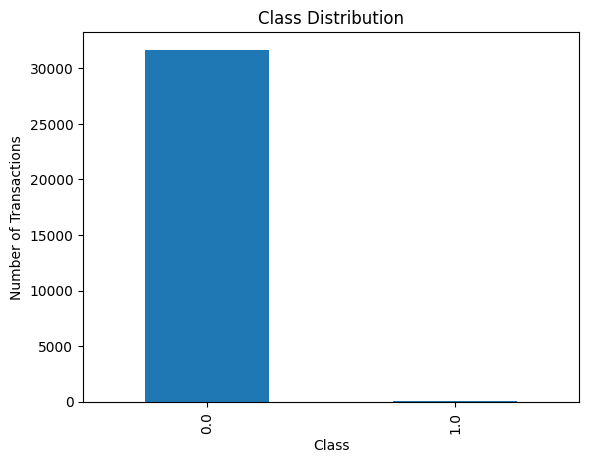

In [ ]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (31780, 30)
Target shape: (31780,)


In [ ]:
print("Dataset shape:", df.shape)

print("\nAll columns:")
for i, column in enumerate(df.columns):
    print(i, "->", column)

Dataset shape: (31780, 31)

All columns:
0 -> Time
1 -> V1
2 -> V2
3 -> V3
4 -> V4
5 -> V5
6 -> V6
7 -> V7
8 -> V8
9 -> V9
10 -> V10
11 -> V11
12 -> V12
13 -> V13
14 -> V14
15 -> V15
16 -> V16
17 -> V17
18 -> V18
19 -> V19
20 -> V20
21 -> V21
22 -> V22
23 -> V23
24 -> V24
25 -> V25
26 -> V26
27 -> V27
28 -> V28
29 -> Amount
30 -> Class


In [ ]:
print("Columns with few unique values:\n")

for column in df.columns:
    unique_count = df[column].nunique(dropna=False)

    if unique_count <= 10:
        print(f"{column} -> {unique_count} unique values")
        print(df[column].value_counts(dropna=False).head(10))
        print("-" * 50)

Columns with few unique values:

Class -> 3 unique values
Class
0.0    31677
1.0      102
NaN        1
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
target_column = "Class"

print("Target column:", target_column)

print("\nTarget values:")
print(df[target_column].value_counts(dropna=False))

Target column: Class

Target values:
Class
0.0    31677
1.0      102
NaN        1
Name: count, dtype: int64


In [ ]:
print("\nMissing target values:")
print(df[target_column].isna().sum())


Missing target values:
1


In [ ]:
X = df.drop(target_column, axis=1)
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (31780, 30)
y shape: (31780,)

Target distribution:
Class
0.0    31677
1.0      102
Name: count, dtype: int64


In [ ]:
print("NaN in X:", X.isna().sum().sum())
print("NaN in y:", y.isna().sum())

NaN in X: 23
NaN in y: 1


In [ ]:
# ================================
# FIX: Remove NaN from target
# ================================

print("Current dataset shape:", df.shape)

# Check target column
print("Target column:", target_column)
print("NaN values in target BEFORE:", df[target_column].isna().sum())

# Remove rows where target is missing
df = df.loc[df[target_column].notna()].copy()

# Recreate X and y AFTER removing NaN rows
X = df.drop(columns=[target_column])
y = df[target_column]

print("\nDataset shape AFTER removing target NaN:", df.shape)
print("NaN values in y AFTER:", y.isna().sum())

print("\nTarget distribution:")
print(y.value_counts(dropna=False))

Current dataset shape: (31780, 31)
Target column: Class
NaN values in target BEFORE: 1

Dataset shape AFTER removing target NaN: (31779, 31)
NaN values in y AFTER: 0

Target distribution:
Class
0.0    31677
1.0      102
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (25423, 30)
Testing data: (6356, 30)

Training class distribution:
Class
0.0    25341
1.0       82
Name: count, dtype: int64

Testing class distribution:
Class
0.0    6336
1.0      20
Name: count, dtype: int64


In [ ]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Legitimate transactions:", negative)
print("Fraudulent transactions:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Legitimate transactions: 25341
Fraudulent transactions: 82
Scale Pos Weight: 309.0365853658537


In [ ]:
print("Missing values in training features:", X_train.isna().sum().sum())
print("Missing values in testing features:", X_test.isna().sum().sum())

Missing values in training features: 0
Missing values in testing features: 0


In [ ]:
print(X_train.dtypes.value_counts())

float64    29
int64       1
Name: count, dtype: int64


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully! ")

XGBoost model trained successfully! 


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully! ")

Predictions generated successfully! 


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      6336
       Fraud       0.89      0.85      0.87        20

    accuracy                           1.00      6356
   macro avg       0.95      0.92      0.94      6356
weighted avg       1.00      1.00      1.00      6356



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6334    2]
 [   3   17]]


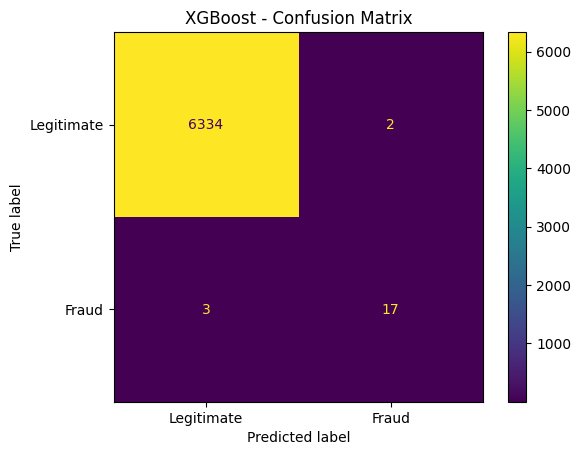

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("===== XGBoost Performance =====")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

===== XGBoost Performance =====
Precision : 0.8947
Recall    : 0.8500
F1 Score  : 0.8718
ROC-AUC   : 0.9825
PR-AUC    : 0.9193


In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives  (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives  (TP):", tp)

True Negatives  (TN): 6334
False Positives (FP): 2
False Negatives (FN): 3
True Positives  (TP): 17


In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

results

,Metric,Score
0,Precision,0.894737
1,Recall,0.850000
2,F1 Score,0.871795
3,ROC-AUC,0.982505
4,PR-AUC,0.919301


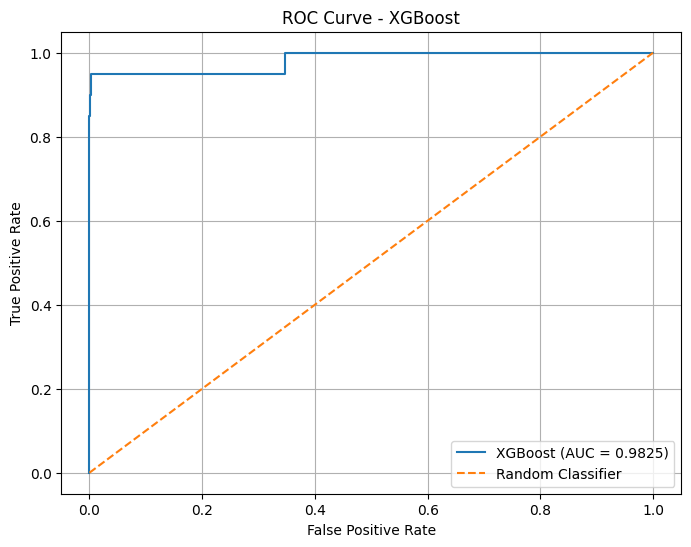

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()

plt.show()

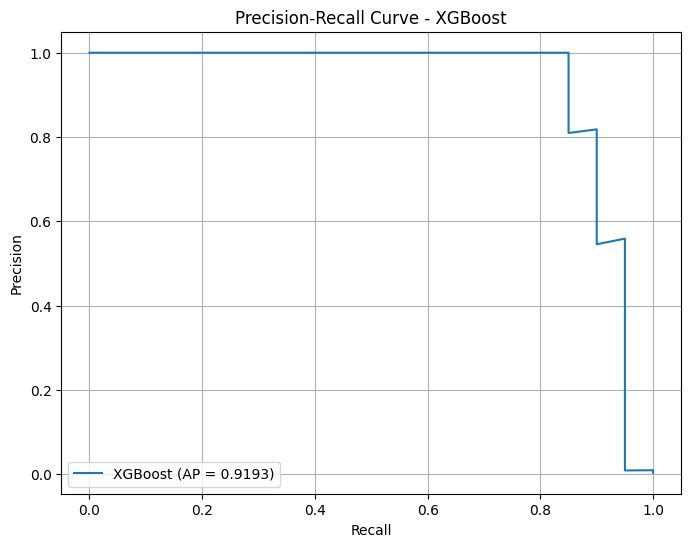

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"XGBoost (AP = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.grid()

plt.show()

In [ ]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
V14       0.584512
V4        0.102736
V12       0.057342
V3        0.055503
V17       0.036553
V21       0.027072
V26       0.017650
V10       0.014580
V27       0.014269
V11       0.008932
V22       0.008424
Amount    0.007010
V5        0.006294
V1        0.006063
V7        0.005455
dtype: float32


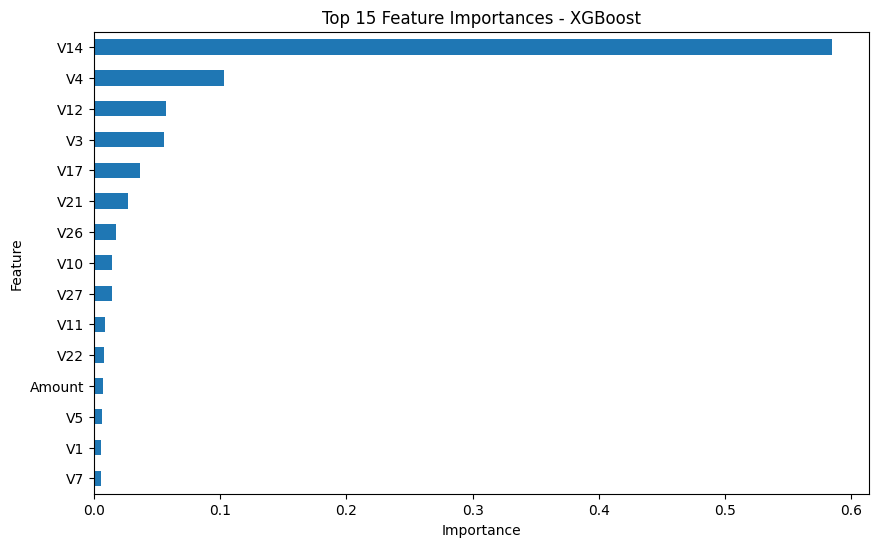

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

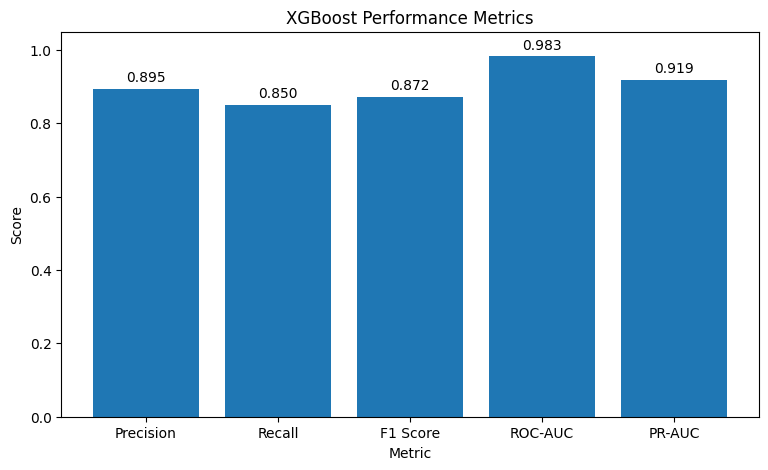

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    performance["Metric"],
    performance["Score"]
)

plt.ylim(0, 1.05)

plt.title("XGBoost Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")

for i, score in enumerate(performance["Score"]):
    plt.text(
        i,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.show()

In [ ]:
fraud_results = X_test.copy()

fraud_results["Actual"] = y_test
fraud_results["Predicted"] = y_pred
fraud_results["Fraud_Probability"] = y_prob

fraud_results[fraud_results["Actual"] == 1][
    ["Actual", "Predicted", "Fraud_Probability"]
]

,Actual,Predicted,Fraud_Probability
4920,1.0,0,0.290597
10498,1.0,0,0.000030
17407,1.0,1,0.999870
30384,1.0,1,0.999560
12108,1.0,1,0.999942
6529,1.0,1,0.999663
6472,1.0,1,0.999945
15476,1.0,1,0.999918
8615,1.0,1,0.999803
8312,1.0,1,0.999936


In [ ]:
missed_fraud = fraud_results[
    (fraud_results["Actual"] == 1) &
    (fraud_results["Predicted"] == 0)
]

print("Fraud transactions missed by model:", len(missed_fraud))

missed_fraud[
    ["Actual", "Predicted", "Fraud_Probability"]
]

Fraud transactions missed by model: 3


,Actual,Predicted,Fraud_Probability
4920,1.0,0,0.290597
10498,1.0,0,0.000030
14338,1.0,0,0.016897


In [ ]:
import joblib

joblib.dump(
    model,
    "credit_card_fraud_xgboost.pkl"
)

print("Model saved successfully as credit_card_fraud_xgboost.pkl")

Model saved successfully as credit_card_fraud_xgboost.pkl


In [ ]:
performance.to_csv(
    "xgboost_fraud_detection_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
